imports

In [2]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph

Define agent state schema | define first node

In [3]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [12]:
def process_values(state: AgentState) -> AgentState:
    """A node that processes the values and updates the result in the state."""
    total = sum(state["values"])

    print(state)

    state["result"] = f"Hello {state['name']}, the sum of your values is {total}."
    
    print(state)
    
    return state

create the graph now

In [13]:
graph = StateGraph(AgentState)
graph.add_node("process_values_node", process_values)   # name, action/function
graph.set_entry_point("process_values_node")
graph.set_finish_point("process_values_node")
app = graph.compile()

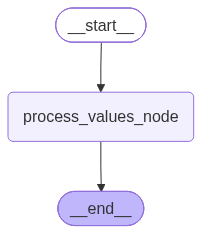

In [14]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

call the graph

In [15]:
ans = app.invoke({"values":[1,4,7], "name":"Matty"})  # invoke the graph with the initial state

{'values': [1, 4, 7], 'name': 'Matty'}
{'values': [1, 4, 7], 'name': 'Matty', 'result': 'Hello Matty, the sum of your values is 12.'}


see the results

In [16]:
ans

{'values': [1, 4, 7],
 'name': 'Matty',
 'result': 'Hello Matty, the sum of your values is 12.'}

In [17]:
ans["result"]  # print the final state after the graph execution

'Hello Matty, the sum of your values is 12.'